<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/01_RNAi_siRNA_miRNA_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: RNA Interference (RNAi) — siRNA & miRNA-Mediated Gene Silencing

**Learning objectives**
- Understand how siRNA and miRNA silence gene expression via mRNA degradation / translational repression
- Design a candidate siRNA against a target mRNA and apply standard design rules
- Simulate seed-based miRNA target prediction on 3′UTR sequences
- Model the kinetics of mRNA degradation and the resulting drop in protein output
- Fit a dose–response (knockdown) curve, as you would from a real siRNA titration experiment

**Background**

RNAi is a post-transcriptional gene-silencing pathway triggered by double-stranded RNA.
- **siRNA** (small interfering RNA, ~21–23 nt, perfectly complementary to its target) is loaded into the RISC complex and directs **cleavage/degradation of the target mRNA**, giving a strong, specific knockdown.
- **miRNA** (micro RNA) is endogenous, only partially complementary (mainly via a 6–8 nt "seed" region, positions 2–8), and typically causes **translational repression and/or mRNA destabilization** of many targets at once.

Mechanism in one line: **RNAi trigger → RISC loading → target mRNA recognition → mRNA degradation → loss of protein production.**


In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from itertools import product

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7,4)
print("Environment ready.")


Environment ready.


## Part 1 — Simulating mRNA Degradation → Loss of Protein Output

We model a simple two-pool kinetic system:

- mRNA is made at a constant transcription rate and degraded at a basal rate.
- Protein is translated from mRNA at a constant rate and degraded at its own rate.
- After siRNA is introduced at t = t0, the **mRNA degradation rate increases sharply** (RISC-mediated cleavage), which is the defining event of RNAi.

This lets you see, quantitatively, why silencing an mRNA takes some time to show up at the protein level (protein has its own, usually slower, turnover).


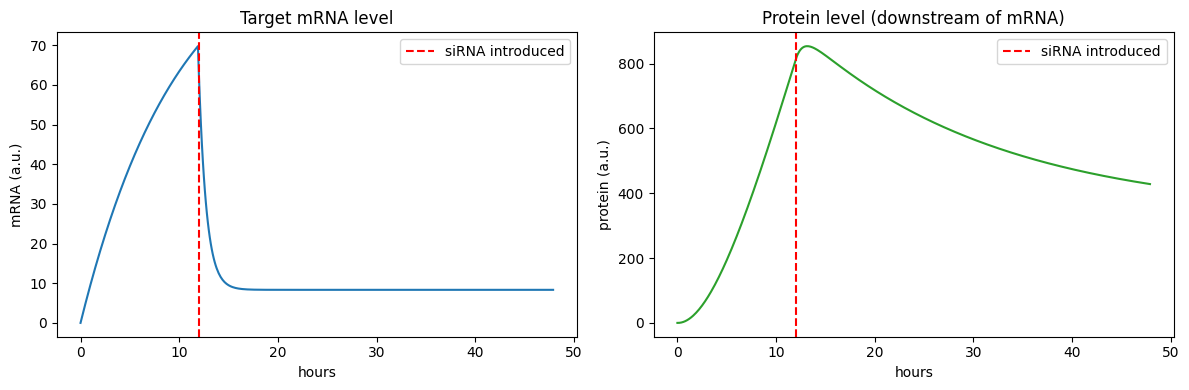

Final mRNA knockdown: 88.1%
Final protein knockdown: 46.7% (note the lag relative to mRNA)


In [ ]:
def simulate_rnai(t_max=48, dt=0.1, siRNA_on_t=12,
                   k_transcribe=10.0, k_mrna_decay=0.1,
                   k_translate=2.0, k_protein_decay=0.05,
                   k_mrna_decay_siRNA=1.2):
    '''Simulate mRNA/protein levels before and after siRNA-triggered degradation.'''
    t = np.arange(0, t_max, dt)
    mRNA = np.zeros_like(t)
    protein = np.zeros_like(t)
    for i in range(1, len(t)):
        decay = k_mrna_decay_siRNA if t[i] >= siRNA_on_t else k_mrna_decay
        dmRNA = k_transcribe - decay * mRNA[i-1]
        dprot = k_translate * mRNA[i-1] - k_protein_decay * protein[i-1]
        mRNA[i] = mRNA[i-1] + dmRNA * dt
        protein[i] = protein[i-1] + dprot * dt
    return t, mRNA, protein

t, mRNA, protein = simulate_rnai()

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(t, mRNA, color='tab:blue')
ax[0].axvline(12, color='red', ls='--', label='siRNA introduced')
ax[0].set_title('Target mRNA level'); ax[0].set_xlabel('hours'); ax[0].set_ylabel('mRNA (a.u.)'); ax[0].legend()

ax[1].plot(t, protein, color='tab:green')
ax[1].axvline(12, color='red', ls='--', label='siRNA introduced')
ax[1].set_title('Protein level (downstream of mRNA)'); ax[1].set_xlabel('hours'); ax[1].set_ylabel('protein (a.u.)'); ax[1].legend()
plt.tight_layout(); plt.show()

pct_knockdown_mrna = 100 * (1 - mRNA[-1]/mRNA[int(12/0.1)-1])
pct_knockdown_protein = 100 * (1 - protein[-1]/protein[int(12/0.1)-1])
print(f"Final mRNA knockdown: {pct_knockdown_mrna:.1f}%")
print(f"Final protein knockdown: {pct_knockdown_protein:.1f}% (note the lag relative to mRNA)")


**Question 1.** Why does the protein curve lag behind the mRNA curve after siRNA is introduced? Which rate constant in the model controls the size of that lag?


## Part 2 — Designing a Candidate siRNA Against a Target mRNA

Standard empirical design rules (simplified, after Reynolds et al. / Ui-Tei et al.):
1. Length 19–21 nt
2. GC content between ~30–52%
3. No long mononucleotide runs (≥4 identical bases in a row) — reduces off-target/immune effects
4. Avoid the very 5′/3′ ends of the mRNA (poor accessibility)
5. Prefer a **uniquely occurring** 19-mer in the transcript, so the siRNA does not have multiple perfect binding sites (this is a crude proxy for off-target specificity)

We'll scan a target mRNA sequence and rank candidate siRNAs.


In [ ]:
# A synthetic (illustrative) target mRNA CDS — replace with a real RefSeq CDS for coursework
target_mrna = (
"ATGGCTAGCAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTGTTGAATTAGATGGTGATGTT"
"AATGGGCACAAATTTTCTGTCAGTGGAGAGGGTGAAGGTGATGCTACATACGGAAAGCTTACCCTTAAA"
"TTTATTTGCACTACTGGAAAACTACCTGTTCCATGGCCAACACTTGTCACTACTTTCGGTTATGGTGTT"
"CAATGCTTTGCGAGATACCCAGATCATATGAAACAGCATGACTTTTTCAAGAGTGCCATGCCCGAAGGT"
"TATGTACAGGAAAGAACTATATTTTTCAAAGATGACGGGAACTACAAGACACGTGCTGAAGTCAAGTTT"
)
target_mrna = target_mrna.replace("\n", "")

def gc_content(seq):
    return 100 * (seq.count('G') + seq.count('C')) / len(seq)

def has_long_run(seq, n=4):
    return bool(re.search(r'(.)\1{' + str(n-1) + ',}', seq))

def revcomp(seq):
    comp = {'A':'T','T':'A','G':'C','C':'G'}
    return ''.join(comp[b] for b in reversed(seq))

window = 21
candidates = []
for i in range(len(target_mrna) - window + 1):
    sense = target_mrna[i:i+window]           # sense strand = same as mRNA (siRNA passenger)
    guide = revcomp(sense)                     # guide strand loaded into RISC, antisense to mRNA
    gc = gc_content(sense)
    ok_gc = 30 <= gc <= 52
    ok_run = not has_long_run(sense)
    occurrences = target_mrna.count(sense)      # crude specificity proxy within this transcript
    candidates.append(dict(pos=i, sense_19_21mer=sense, guide_strand=guide,
                            gc_pct=round(gc,1), passes_gc=ok_gc, no_long_run=ok_run,
                            unique_in_transcript=(occurrences==1)))

df = pd.DataFrame(candidates)
df['pass_all_filters'] = df['passes_gc'] & df['no_long_run'] & df['unique_in_transcript']
ranked = df[df['pass_all_filters']].sort_values('gc_pct', key=lambda s: (s-40).abs()).reset_index(drop=True)
print(f"{len(ranked)} candidate siRNAs pass all filters out of {len(df)} windows scanned.\n")
ranked.head(10)


158 candidate siRNAs pass all filters out of 325 windows scanned.



,pos,sense_19_21mer,guide_strand,gc_pct,passes_gc,no_long_run,unique_in_transcript,pass_all_filters
0,4,CTAGCAAAGGAGAAGAACTTT,AAAGTTCTTCTCCTTTGCTAG,38.1,True,True,True,True
1,32,AGTTGTCCCAATTCTTGTTGA,TCAACAAGAATTGGGACAACT,38.1,True,True,True,True
2,33,GTTGTCCCAATTCTTGTTGAA,TTCAACAAGAATTGGGACAAC,38.1,True,True,True,True
3,54,TTAGATGGTGATGTTAATGGG,CCCATTAACATCACCATCTAA,38.1,True,True,True,True
4,119,CGGAAAGCTTACCCTTAAATT,AATTTAAGGGTAAGCTTTCCG,38.1,True,True,True,True
5,118,ACGGAAAGCTTACCCTTAAAT,ATTTAAGGGTAAGCTTTCCGT,38.1,True,True,True,True
6,117,TACGGAAAGCTTACCCTTAAA,TTTAAGGGTAAGCTTTCCGTA,38.1,True,True,True,True
7,61,GTGATGTTAATGGGCACAAAT,ATTTGTGCCCATTAACATCAC,38.1,True,True,True,True
8,109,ATGCTACATACGGAAAGCTTA,TAAGCTTTCCGTATGTAGCAT,38.1,True,True,True,True
9,116,ATACGGAAAGCTTACCCTTAA,TTAAGGGTAAGCTTTCCGTAT,38.1,True,True,True,True


**Question 2.** Pick your top-ranked candidate. What would you check next in a real design pipeline (hint: think about genome-wide, not just transcript-local, specificity)?


## Part 3 — miRNA Seed-Match Target Prediction

miRNA target recognition mostly depends on **Watson–Crick pairing of the miRNA "seed" (nt 2–8)** to sites in the target's 3′UTR. We'll scan a set of 3′UTR sequences for seed matches to a given miRNA and score candidate target sites (6mer / 7mer-A1 / 7mer-m8 / 8mer, following the standard TargetScan nomenclature).


In [ ]:
def seed_match_type(utr, seed_rc, downstream_A):
    '''Classify seed match type at every occurrence of the 6-mer seed complement in the UTR.'''
    matches = []
    start = 0
    while True:
        idx = utr.find(seed_rc, start)
        if idx == -1:
            break
        has_A1 = (idx+len(seed_rc) < len(utr)) and (utr[idx+len(seed_rc)] == 'A')
        has_m8 = (idx-1 >= 0) and (utr[idx-1] == downstream_A)  # simplified proxy for position-8 match
        if has_A1 and has_m8:
            site_type = "8mer"
        elif has_A1:
            site_type = "7mer-A1"
        elif has_m8:
            site_type = "7mer-m8"
        else:
            site_type = "6mer"
        matches.append((idx, site_type))
        start = idx + 1
    return matches

mirna = "UGAGGUAGUAGGUUGUAUAGUU"   # let-7a-5p (RNA, 5'->3')
mirna_dna = mirna.replace('U','T')
seed = mirna_dna[1:8]             # nt 2-8 (seed region)
seed_rc = revcomp(seed)           # what we look for in the target 3'UTR (DNA alphabet)

utrs = {
 "GeneA_3UTR": "CTAGCTTTGAGACCTAAGCT" + seed_rc + "AGGCCTAGGGATCCGTTAGC",
 "GeneB_3UTR": "GGGCCATTTAGCTAGCATTAGCGGATCCTAGCTTAGCTTGACCA",
 "GeneC_3UTR": "TTAG" + seed_rc + "ACCTGAGCTAGCTAGCTAGCTTTAG" + seed_rc + "GGGCTA",
}

rows = []
for gene, utr in utrs.items():
    hits = seed_match_type(utr, seed_rc, downstream_A='A')
    if hits:
        for idx, site_type in hits:
            rows.append(dict(gene=gene, position=idx, site_type=site_type))
    else:
        rows.append(dict(gene=gene, position=None, site_type="no seed match"))

mirna_targets = pd.DataFrame(rows)
print(f"miRNA: let-7a-5p | seed (nt2-8): {seed} | searching for complement: {seed_rc}\n")
mirna_targets


miRNA: let-7a-5p | seed (nt2-8): GAGGTAG | searching for complement: CTACCTC



,gene,position,site_type
0,GeneA_3UTR,20.0,7mer-A1
1,GeneB_3UTR,NaN,no seed match
2,GeneC_3UTR,4.0,7mer-A1
3,GeneC_3UTR,36.0,6mer


**Question 3.** GeneC has two predicted seed sites. Based on what you know about miRNA-mediated repression, would you expect GeneC to be *more* or *less* strongly repressed than a single-site target, and why?


## Part 4 — Dose–Response Knockdown Curve

In a real siRNA transfection experiment, you'd measure residual mRNA/protein at several siRNA concentrations (qPCR or Western blot / reporter assay) and fit a sigmoidal dose–response curve to extract an **IC50** (concentration giving 50% knockdown).


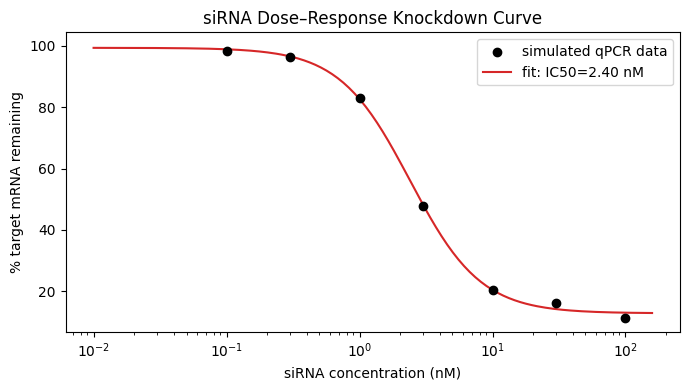

Fitted IC50 = 2.40 nM (ground truth used to simulate data: 2.5 nM)


In [ ]:
from scipy.optimize import curve_fit

def hill_knockdown(conc, ic50, hill, top, bottom):
    return bottom + (top - bottom) / (1 + (conc/ic50)**hill)

# Simulated qPCR-style knockdown data (% mRNA remaining) across an siRNA dilution series
conc_nM = np.array([0, 0.1, 0.3, 1, 3, 10, 30, 100])
true_ic50, true_hill = 2.5, 1.3
pct_remaining = hill_knockdown(conc_nM, true_ic50, true_hill, top=100, bottom=8)
pct_remaining_noisy = pct_remaining + np.random.normal(0, 3, size=conc_nM.shape)
pct_remaining_noisy[0] = 100  # untreated control fixed at 100%

popt, _ = curve_fit(hill_knockdown, conc_nM, pct_remaining_noisy,
                     p0=[1, 1, 100, 0], bounds=([0,0.1,90,0],[1000,10,110,50]))
fit_ic50, fit_hill, fit_top, fit_bottom = popt

x_smooth = np.logspace(-2, 2.2, 200)
y_smooth = hill_knockdown(x_smooth, *popt)

plt.figure()
plt.scatter(conc_nM, pct_remaining_noisy, color='black', zorder=5, label='simulated qPCR data')
plt.plot(x_smooth, y_smooth, color='tab:red', label=f'fit: IC50={fit_ic50:.2f} nM')
plt.xscale('log')
plt.xlabel('siRNA concentration (nM)')
plt.ylabel('% target mRNA remaining')
plt.title('siRNA Dose–Response Knockdown Curve')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Fitted IC50 = {fit_ic50:.2f} nM (ground truth used to simulate data: {true_ic50} nM)")


## Wrap-up Exercises

1. Re-run Part 1 with `k_mrna_decay_siRNA` lowered to 0.3 (a "weak" siRNA). How does the knockdown depth and kinetics change?
2. In Part 2, add a rule that also rejects any 19–21mer containing a **TTTT** run specifically (Pol III termination signal — relevant if you were expressing this as a short hairpin, shRNA). How many candidates survive?
3. In Part 3, try a different miRNA seed (look up a real one, e.g. miR-21-5p) and rescan the same UTRs.
4. In Part 4, what does a **shallower Hill slope** (lower `hill`) imply biologically about the knockdown mechanism/uniformity across a cell population?

---
*This notebook uses simulated/illustrative sequences and kinetics for teaching purposes. For real analyses, substitute actual RefSeq/Ensembl transcript sequences and experimental qPCR/Western data.*
